# Spatial EDA (Chunked) Notebook

This notebook reproduces `spatial_pipeline_chunked.py` outputs and visualization artifacts.

In [20]:
import os
from pathlib import Path

TARGET = Path(r"D:\AAA_nus\Sem2\IT5006\project")
os.chdir(TARGET)
print("Now CWD =", Path.cwd())


Now CWD = D:\AAA_nus\Sem2\IT5006\project


In [21]:
from pathlib import Path

# 当前 notebook 所在目录
NOTEBOOK_DIR = Path.cwd()

# 如果你在 project/notebooks 里运行
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

FIG_DIR = PROJECT_ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("FIG_DIR =", FIG_DIR)


PROJECT_ROOT = D:\AAA_nus\Sem2\IT5006\project
FIG_DIR = D:\AAA_nus\Sem2\IT5006\project\docs\figures


In [22]:
import os
import time
from io import StringIO
from collections import Counter

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

import folium
from folium.plugins import HeatMap
from IPython.display import display

In [23]:
# ---------------------------
# Config (same as script)
# ---------------------------
BASE = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv"

START_DATE = "2015-01-01T00:00:00.000"
END_DATE   = "2025-01-01T00:00:00.000"   # exclusive

SELECT = "date,primary_type,latitude,longitude,district,community_area,location_description"

LIMIT = 50000
SLEEP_SEC = 0.10

GRID = 0.01

SAMPLE_EACH_CHUNK = 1000
MAX_SAMPLE_POINTS = 80000

HEATMAP_TOPK_GRIDS = 400

OUT_AREA_CSV  = "data/processed/area_counts.csv"
OUT_GRID_CSV  = "data/processed/grid_counts.csv"
OUT_HEXBIN_PNG = "docs/figures/hexbin_density.png"
OUT_TOP10_PNG  = "docs/figures/top10_district.png"
OUT_HOTSPOT_HTML = "docs/figures/hotspot_map.html"

APP_TOKEN = os.environ.get("CHICAGO_APP_TOKEN", "").strip()

In [24]:
# ---------------------------
# Helpers
# ---------------------------
def ensure_dirs():
    os.makedirs(os.path.dirname(OUT_AREA_CSV), exist_ok=True)
    os.makedirs(os.path.dirname(OUT_GRID_CSV), exist_ok=True)
    os.makedirs(os.path.dirname(OUT_HEXBIN_PNG), exist_ok=True)
    os.makedirs(os.path.dirname(OUT_HOTSPOT_HTML), exist_ok=True)

def build_where():
    return (
        f"date >= '{START_DATE}' AND date < '{END_DATE}' "
        "AND latitude IS NOT NULL AND longitude IS NOT NULL"
    )

def request_chunk(offset: int, session: requests.Session, max_retries: int = 6) -> pd.DataFrame:
    params = {
        "$select": SELECT,
        "$where": build_where(),
        "$order": "date ASC",
        "$limit": LIMIT,
        "$offset": offset,
    }
    if APP_TOKEN:
        params["$$app_token"] = APP_TOKEN

    backoff = 1.0
    last_error = None
    for _ in range(max_retries):
        try:
            r = session.get(BASE, params=params, timeout=60)
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(backoff)
                backoff = min(backoff * 2.0, 30.0)
                continue
            r.raise_for_status()
            return pd.read_csv(StringIO(r.text))
        except (requests.RequestException, pd.errors.ParserError) as e:
            last_error = e
            time.sleep(backoff)
            backoff = min(backoff * 2.0, 30.0)

    if last_error is not None:
        raise last_error
    return pd.DataFrame()

def cap_sample_points(sample_latlon: list, max_points: int, rng: np.random.Generator) -> list:
    n = len(sample_latlon)
    if n <= max_points:
        return sample_latlon
    idx = rng.choice(n, size=max_points, replace=False)
    return [sample_latlon[i] for i in idx]

In [25]:
###Wenn added###
#放在 pipeline 之前（while True 之前）
#定义缓存路径

from pathlib import Path
import pickle

CACHE_DIR = Path("data/processed")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

SPATIAL_CACHE = CACHE_DIR / "spatial_counters.pkl"
print("SPATIAL_CACHE =", SPATIAL_CACHE.resolve())


SPATIAL_CACHE = D:\AAA_nus\Sem2\IT5006\project\data\processed\spatial_counters.pkl


In [26]:
# ---------------------------
# Main pipeline
# ---------------------------

#while True 整段包进 else
#如果有缓存就直接读并跳过 API
from collections import Counter

if SPATIAL_CACHE.exists():
    print("✅ Loading spatial cache, skipping API:", SPATIAL_CACHE)
    with open(SPATIAL_CACHE, "rb") as f:
        payload = pickle.load(f)
    district_counter = payload["district_counter"]
    grid_counter = payload["grid_counter"]
    sample_latlon = payload["sample_latlon"]
    total_rows_seen = payload.get("total_rows_seen", None)
else:
    print("⚠️ No cache found. Running API pipeline ONCE...")
    ensure_dirs()

    district_counter = Counter()
    grid_counter = Counter()
    sample_latlon = []
    total_rows_seen = 0

    offset = 0
    session = requests.Session()

    while True:
        chunk = request_chunk(offset, session=session)
        if chunk.empty:
            break

        total_rows_seen += len(chunk)

        chunk["latitude"] = pd.to_numeric(chunk["latitude"], errors="coerce")
        chunk["longitude"] = pd.to_numeric(chunk["longitude"], errors="coerce")
        chunk = chunk.dropna(subset=["latitude", "longitude"])

        if "district" in chunk.columns:
            d = pd.to_numeric(chunk["district"], errors="coerce").dropna().astype(int)
            district_counter.update(d.value_counts().to_dict())

        lat_bin = (chunk["latitude"] / GRID).round().astype(int)
        lon_bin = (chunk["longitude"] / GRID).round().astype(int)
        grid_keys = list(zip(lat_bin.tolist(), lon_bin.tolist()))
        grid_counter.update(Counter(grid_keys))

        if SAMPLE_EACH_CHUNK > 0:
            rng = np.random.default_rng(seed=offset)
            take = min(SAMPLE_EACH_CHUNK, len(chunk))
            if take > 0:
                idx = rng.choice(len(chunk), size=take, replace=False)
                pts = list(zip(chunk["latitude"].to_numpy()[idx], chunk["longitude"].to_numpy()[idx]))
                sample_latlon.extend(pts)
                sample_latlon = cap_sample_points(sample_latlon, MAX_SAMPLE_POINTS, rng)

        offset += LIMIT
        print(f"rows so far (requested): {offset} | rows received (kept): {total_rows_seen}")
        time.sleep(SLEEP_SEC)

    if len(district_counter) == 0:
        raise RuntimeError("No district data collected. Check that 'district' is available in your chunks.")

    # ✅ Save cache at the end (关键：只跑一次)
    payload = {
        "district_counter": district_counter,
        "grid_counter": grid_counter,
        "sample_latlon": sample_latlon,
        "total_rows_seen": total_rows_seen
    }
    with open(SPATIAL_CACHE, "wb") as f:
        pickle.dump(payload, f)

    print("✅ Saved spatial cache:", SPATIAL_CACHE.resolve())


✅ Loading spatial cache, skipping API: data\processed\spatial_counters.pkl


In [27]:
# ---------------------------
# area_counts.csv
# ---------------------------
area_df = (
    pd.DataFrame({"district": list(district_counter.keys()), "crime_count": list(district_counter.values())})
    .sort_values("crime_count", ascending=False)
    .reset_index(drop=True)
)
total_crimes = area_df["crime_count"].sum()
area_df["share"] = area_df["crime_count"] / total_crimes
area_df["cum_share"] = area_df["share"].cumsum()
area_df.to_csv(OUT_AREA_CSV, index=False)
area_df.head(10)

,district,crime_count,share,cum_share
0,11,161040,0.065007,0.065007
1,8,156751,0.063276,0.128282
2,6,153700,0.062044,0.190326
3,4,139764,0.056418,0.246745
4,12,131712,0.053168,0.299913
5,25,130033,0.052490,0.352403
6,1,129614,0.052321,0.404724
7,18,127091,0.051303,0.456027
8,7,124494,0.050254,0.506281
9,3,121254,0.048947,0.555228


In [29]:
# ---------------------------
# grid_counts.csv
# ---------------------------
grid_items = list(grid_counter.items())
grid_df = pd.DataFrame(grid_items, columns=["grid_key", "count"])
grid_df[["lat_bin", "lon_bin"]] = pd.DataFrame(grid_df["grid_key"].tolist(), index=grid_df.index)
grid_df = grid_df.drop(columns=["grid_key"]).sort_values("count", ascending=False).reset_index(drop=True)
grid_df["lat_center"] = grid_df["lat_bin"] * GRID
grid_df["lon_center"] = grid_df["lon_bin"] * GRID
#grid_df.to_csv(OUT_GRID_CSV, index=False)
from pathlib import Path

# 强制保存到 project 目录
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUT_DIR = PROJECT_ROOT / "docs" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

new_path = OUT_DIR / "grid_counts_2015_2024.csv"

grid_df.to_csv(new_path, index=False)

print("Saved to:", new_path.resolve())

grid_df.head(10)

Saved to: D:\AAA_nus\Sem2\IT5006\project\docs\outputs\grid_counts_2015_2024.csv


,count,lat_bin,lon_bin,lat_center,lon_center
0,40374,4188,-8763,41.88,-87.63
1,36085,4189,-8763,41.89,-87.63
2,21058,4190,-8763,41.90,-87.63
3,19844,4189,-8762,41.89,-87.62
4,17253,4188,-8775,41.88,-87.75
5,16594,4188,-8773,41.88,-87.73
6,16038,4187,-8763,41.87,-87.63
7,15560,4187,-8772,41.87,-87.72
8,15287,4175,-8760,41.75,-87.60
9,15155,4190,-8772,41.90,-87.72


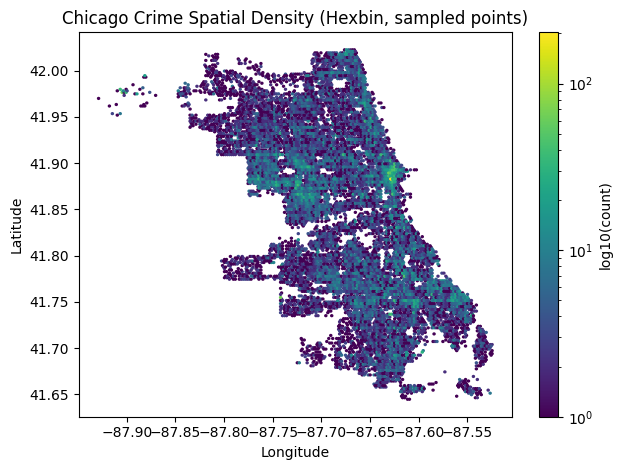

In [13]:
# ---------------------------
# Figure 1: hexbin_density.png
# ---------------------------
if len(sample_latlon) < 1000:
    print("Warning: too few sampled points for hexbin; consider increasing SAMPLE_EACH_CHUNK or MAX_SAMPLE_POINTS.")

lats = np.array([p[0] for p in sample_latlon], dtype=np.float64)
lons = np.array([p[1] for p in sample_latlon], dtype=np.float64)

plt.figure()
hb = plt.hexbin(lons, lats, gridsize=200, bins="log")
plt.colorbar(hb, label="log10(count)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Chicago Crime Spatial Density (Hexbin, sampled points)")
plt.tight_layout()
plt.savefig(OUT_HEXBIN_PNG, dpi=200)
plt.show()
plt.close()

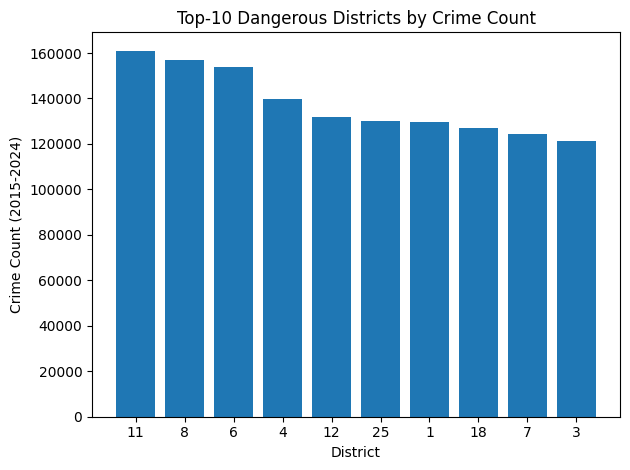

In [10]:
# ---------------------------
# Figure 2: top10_district.png
# ---------------------------
top10 = area_df.head(10).copy()

plt.figure()
plt.bar(top10["district"].astype(str), top10["crime_count"].to_numpy())
plt.xlabel("District")
plt.ylabel("Crime Count (2015-2024)")
plt.title("Top-10 Dangerous Districts by Crime Count")
plt.tight_layout()
plt.savefig(OUT_TOP10_PNG, dpi=200)
plt.show()
plt.close()

In [24]:
# ---------------------------
# Figure 3: hotspot_map.html
# ---------------------------
hot = grid_df.head(HEATMAP_TOPK_GRIDS).copy()
center_lat = float(np.median(lats)) if len(lats) else float(hot["lat_center"].median())
center_lon = float(np.median(lons)) if len(lons) else float(hot["lon_center"].median())

m = folium.Map(location=[center_lat, center_lon], zoom_start=10)
heat_data = hot[["lat_center", "lon_center", "count"]].values.tolist()
HeatMap(heat_data, radius=18, blur=14, max_zoom=13).add_to(m)

#m.save(OUT_HOTSPOT_HTML)
# os.makedirs("docs/figures", exist_ok=True)
# m.save("docs/figures/hotspot_map.html")
# import os
# os.makedirs("docs/figures", exist_ok=True)
# m.save("docs/figures/hotspot_map.html")
# print("Saved hotspot_map.html")
import os
os.makedirs("docs/figures", exist_ok=True)
out_path = os.path.abspath("docs/figures/hotspot_map.html")
m.save(out_path)
print("Saved to:", out_path)



display(m)

Saved to: D:\AAA_nus\Sem2\IT5006\project\docs\figures\hotspot_map.html


In [ ]:
# ---------------------------
# Required conclusion print
# ---------------------------
top10_share = float(top10["crime_count"].sum() / total_crimes)

print("Done.")
print(f"Total crimes counted (district-available): {total_crimes:,}")
print(f"Top-10 districts share: {top10_share:.3%}")
print(f"Saved: {OUT_AREA_CSV}")
print(f"Saved: {OUT_GRID_CSV}")
print(f"Saved: {OUT_HEXBIN_PNG}")
print(f"Saved: {OUT_TOP10_PNG}")
print(f"Saved: {OUT_HOTSPOT_HTML}")

print(
    f"Top-10 districts account for {top10_share:.1%} of all district-tagged crimes (2015-2024), indicating strong spatial concentration."
)
print(
    "Hotspots identified via grid-based aggregation (GRID=0.01°) remain stable and are suitable for stakeholder-facing hotspot visualization."
)

NameError: name 'top10' is not defined